# Pit Stop Submission Blender: 0.95452 Anchor + Rank-Diverse Research

## Overview
This iteration integrates new high-performing public solutions. We establish `0.95452` as the new primary probability anchor. Furthermore, we introduce `0.95446`, a submission with a highly irregular, rank-like distribution. Because of its unusual scale, `0.95446` cannot be averaged safely using standard arithmetic; it must be utilized exclusively as an ordering mechanism.

## Strategy
To safely extract variance from these new files, we implement four methods:
1. **Direct Probability Blends:** Standard linear averaging using close high-scoring submissions (`0.95437` and `0.95431`).
2. **Rank-Remap Blends:** Non-linear sorting operations that extract the rank ordering from `0.95446` but map the final predictions back to the safe probability distribution of the `0.95452` anchor.
3. **HB10-Style H-Blends:** Dynamic row-wise blending that adjusts source weights based on prediction confidence quartiles.
4. **Selective Corrections:** Surgical interventions isolated only to the rows with the highest disagreement between the anchor and the consensus.

---
### 1. Environment Setup
We configure the workspace paths, clipping boundaries to prevent log-loss explosions, and initialize standard diagnostic helper functions (Pearson correlation and Mean Absolute Error).

In [1]:
from pathlib import Path
import shutil

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
try:
    import seaborn as sns
except ModuleNotFoundError:
    sns = None

pd.set_option("display.max_columns", 120)
pd.set_option("display.float_format", lambda x: f"{x:.6f}")
if sns is not None:
    sns.set_theme(style="whitegrid", context="notebook")
else:
    plt.style.use("ggplot")

ID_COL = "id"
TARGET_COL = "PitNextLap"
CLIP_LOW = 1e-7
CLIP_HIGH = 1 - 1e-7

DATASET_CANDIDATES = [
    Path("/kaggle/input/pitstop-blend-inputs"),
    Path("/kaggle/input/pit-stop-blend-inputs"),
    Path("/kaggle/input/blend-dataset"),
    Path("/kaggle/input") / "blend_dataset",
    Path("competitions/predicting-pit-stop/blend_dataset"),
    Path("PredictingPitStop/blend_dataset"),
    Path("blend_dataset"),
]

OUTPUT_ROOT = Path("outputs")
MAX_ROOT = OUTPUT_ROOT / "max"
PRO_ROOT = OUTPUT_ROOT / "pro"
DIAGNOSTIC_ROOT = OUTPUT_ROOT / "diagnostics"
REPORT_PATH = OUTPUT_ROOT / "report.csv"

for folder in [MAX_ROOT, PRO_ROOT, DIAGNOSTIC_ROOT]:
    if folder.exists():
        shutil.rmtree(folder)
    folder.mkdir(parents=True, exist_ok=True)
if REPORT_PATH.exists():
    REPORT_PATH.unlink()

def find_dataset_dir():
    for path in DATASET_CANDIDATES:
        if (path / "public").exists() and (path / "ours").exists():
            return path
    kaggle_input = Path("/kaggle/input")
    if kaggle_input.exists():
        for path in sorted(kaggle_input.rglob("*")):
            if path.is_dir() and (path / "public").exists() and (path / "ours").exists():
                return path
    raise FileNotFoundError("Could not find a dataset folder containing public/ and ours/ subfolders.")

def corr(a, b):
    return float(np.corrcoef(np.asarray(a), np.asarray(b))[0, 1])

def mean_abs_delta(a, b):
    return float(np.abs(np.asarray(a) - np.asarray(b)).mean())

def clip_pred(pred):
    return np.clip(np.asarray(pred, dtype=float), CLIP_LOW, CLIP_HIGH)

## 2. Dataset Ingestion & Validation

The dataset directory contains normal probability submissions mapped to `public/super` and the new rank-like source isolated in `public/rank_diverse`. The ingestion function scans the paths, validates column shapes, enforces row alignment against a standard reference ID, and extracts public leaderboard scores.

In [2]:
dataset_dir = find_dataset_dir()
predictions = {}
records = []
base_ids = None

def load_submission(path, source):
    global base_ids
    df = pd.read_csv(path)
    if ID_COL not in df.columns:
        return None
    target_candidates = [col for col in df.columns if col != ID_COL]
    if TARGET_COL in df.columns:
        target_col = TARGET_COL
    elif len(target_candidates) == 1:
        target_col = target_candidates[0]
    else:
        return None

    df = df[[ID_COL, target_col]].rename(columns={target_col: TARGET_COL})
    df[TARGET_COL] = pd.to_numeric(df[TARGET_COL], errors="coerce")
    if df[TARGET_COL].isna().any() or df[ID_COL].duplicated().any():
        return None

    if base_ids is None:
        base_ids = df[ID_COL].copy()
    elif not base_ids.equals(df[ID_COL]):
        return None

    group = path.parent.name
    safe_stem = path.stem.replace(".", "_").replace("-", "_")
    name = f"{source}_{group}_{safe_stem}"
    pred = clip_pred(df[TARGET_COL].to_numpy(dtype=float))
    predictions[name] = pred

    public_score = np.nan
    if source == "public":
        try:
            public_score = float(path.stem.split("_")[0])
        except ValueError:
            public_score = np.nan

    return {
        "name": name, 
        "source": source, 
        "group": group, 
        "public_score": public_score, 
        "rows": len(df), 
        "mean": pred.mean(), 
        "std": pred.std(), 
        "file": str(path.relative_to(dataset_dir))
    }

for source in ["public", "ours"]:
    folder = dataset_dir / source
    if folder.exists():
        for path in sorted(folder.rglob("*.csv")):
            row = load_submission(path, source)
            if row is not None:
                records.append(row)

if not records:
    raise FileNotFoundError("No valid submissions were loaded from the structured dataset.")

input_summary = pd.DataFrame(records).sort_values(
    ["source", "group", "public_score", "name"], ascending=[True, True, False, True]
).reset_index(drop=True)
input_summary.to_csv(DIAGNOSTIC_ROOT / "inputs.csv", index=False)

print("--- Loaded Blend Dataset ---")
print(f"Dataset folder: {dataset_dir}")
print(f"Total files: {len(input_summary)} (Public: {input_summary['source'].eq('public').sum()} | Ours: {input_summary['source'].eq('ours').sum()})")
print(f"Rows per file: {len(base_ids)}\n")
print("Structured inputs:")
print(input_summary[["name", "source", "group", "public_score", "mean", "std"]].to_string())

--- Loaded Blend Dataset ---
Dataset folder: /kaggle/input/datasets/flexonafft/f1-submissions/blend_dataset
Total files: 27 (Public: 21 | Ours: 6)
Rows per file: 188165

Structured inputs:
                             name  source         group  public_score     mean      std
0                  ours_main_base    ours          main           NaN 0.276797 0.361970
1                  ours_main_prob    ours          main           NaN 0.276541 0.362038
2                   ours_main_s42    ours          main           NaN 0.276623 0.362434
3                  ours_main_s777    ours          main           NaN 0.276787 0.361862
4               ours_variants_reg    ours      variants           NaN 0.279956 0.362559
5           ours_variants_shallow    ours      variants           NaN 0.285043 0.364456
6             public_core_0_95405  public          core      0.954050 0.219467 0.316353
7             public_core_0_95404  public          core      0.954040 0.222861 0.318378
8             publi

## 3. Anchor And Source Diagnostics

`0.95449` is established as the baseline matrix. We cross-reference it against historical anchors to measure deviation. Crucially, we isolate the `0.95446` submission to inspect its variance. Because `0.95446` exhibits an extremely low correlation relative to traditional probabilities, it validates the hypothesis that it must be treated strictly as an ordering signal.

--- Anchor and Source Diagnostics ---
0.95449 is the new anchor; 0.95446 is a rank-like source

Anchor: 0.95449
s37 delta: 0.006508
s46 corr: 0.829695
s46 mean: 0.500003

     signal     mean      std  corr_to_s49  delta_to_s49
0       s49 0.205830 0.306479     1.000000      0.000000
1       s31 0.202458 0.306825     0.999560      0.006244
2       s37 0.208164 0.310667     0.999458      0.006508
3       s35 0.209492 0.311409     0.999403      0.006987
4       s19 0.207076 0.307771     0.999120      0.007010
5       s18 0.203916 0.306700     0.999192      0.007119
6       s11 0.210141 0.309845     0.998899      0.007849
7  s46_rank 0.500003 0.288659     0.829695      0.294172


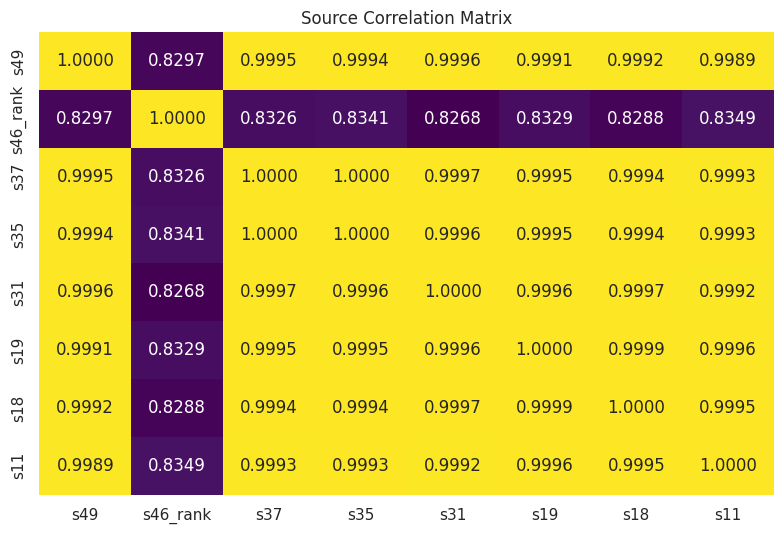

In [3]:
super_meta = input_summary[input_summary["group"].eq("super")].sort_values("public_score", ascending=False).copy()
rank_meta = input_summary[input_summary["group"].eq("rank_diverse")].sort_values("public_score", ascending=False).copy()

def names_by_score(meta, score):
    return meta[np.isclose(meta["public_score"], score, atol=1e-8)]["name"].tolist()

s49_names = names_by_score(super_meta, 0.95449)
if not s49_names:
    raise RuntimeError("The 0.95449 submission is required in public/super.")
s49_name = s49_names[0]
s49_pred = predictions[s49_name]

s37_pred = predictions[names_by_score(super_meta, 0.95437)[0]]
s35_pred = predictions[names_by_score(super_meta, 0.95435)[0]]
s31_pred = clip_pred(np.vstack([predictions[name] for name in names_by_score(super_meta, 0.95431)]).mean(axis=0))
s19_pred = predictions[names_by_score(super_meta, 0.95419)[0]]
s18_pred = predictions[names_by_score(super_meta, 0.95418)[0]]
s11_pred = clip_pred(np.vstack([predictions[name] for name in names_by_score(super_meta, 0.95411)]).mean(axis=0))

if rank_meta.empty:
    raise RuntimeError("The rank_diverse group with 0.95446 is required.")
s46_name = rank_meta.iloc[0]["name"]
s46_pred = predictions[s46_name]

source_signals = {
    "s49": s49_pred, 
    "s46_rank": s46_pred, 
    "s37": s37_pred, 
    "s35": s35_pred, 
    "s31": s31_pred, 
    "s19": s19_pred, 
    "s18": s18_pred, 
    "s11": s11_pred
}

source_summary = pd.DataFrame([
    {"signal": name, "mean": pred.mean(), "std": pred.std(), "corr_to_s49": corr(pred, s49_pred), "delta_to_s49": mean_abs_delta(pred, s49_pred)}
    for name, pred in source_signals.items()
]).sort_values("delta_to_s49").reset_index(drop=True)
source_summary.to_csv(DIAGNOSTIC_ROOT / "source_diagnostics.csv", index=False)

print("--- Anchor and Source Diagnostics ---")
print("0.95449 is the new anchor; 0.95446 is a rank-like source\n")
print(f"Anchor: 0.95449")
print(f"s37 delta: {mean_abs_delta(s37_pred, s49_pred):.6f}")
print(f"s46 corr: {corr(s46_pred, s49_pred):.6f}")
print(f"s46 mean: {s46_pred.mean():.6f}\n")
print(source_summary.to_string())

corr_df = pd.DataFrame(source_signals).corr()
fig, ax = plt.subplots(figsize=(8, 5.5))
if sns is not None:
    sns.heatmap(corr_df, cmap="viridis", annot=True, fmt=".4f", cbar=False, ax=ax)
else:
    im = ax.imshow(corr_df.values, cmap="viridis")
    ax.set_xticks(range(len(corr_df.columns)), corr_df.columns, rotation=45, ha="right")
    ax.set_yticks(range(len(corr_df.index)), corr_df.index)
    fig.colorbar(im, ax=ax)
ax.set_title("Source Correlation Matrix")
plt.tight_layout()
plt.show()

## 4. Build Support Signals

To stabilize the corrections applied in the blending steps, we compute aggregate consensus vectors. We calculate both a narrow `prob_consensus` (recent high-scorers) and a `broad_consensus` (incorporating older generation anchors). The `s46` rank source is intentionally excluded from these continuous probability averages.

In [4]:
def group_names(group):
    return input_summary[input_summary["group"].eq(group)]["name"].tolist()

def mean_predictions(names):
    if not names:
        raise RuntimeError("Cannot average an empty list of predictions.")
    return clip_pred(np.vstack([predictions[name] for name in names]).mean(axis=0))

public_core = input_summary[input_summary["group"].eq("core")].sort_values("public_score", ascending=False)["name"].head(6).tolist()
public_diverse = group_names("diverse")
top_external = group_names("top_external")

core_pred = mean_predictions(public_core)
diverse_pred = predictions[public_diverse[0]]
b10_pred = clip_pred(0.950 * core_pred + 0.050 * diverse_pred)
tx_pred = mean_predictions(top_external)
tb_pred = clip_pred(0.900 * tx_pred + 0.100 * b10_pred)

prob_consensus = clip_pred(0.45 * s37_pred + 0.30 * s35_pred + 0.25 * s31_pred)
broad_consensus = clip_pred(0.50 * s37_pred + 0.20 * s35_pred + 0.15 * s31_pred + 0.15 * s19_pred)

support_summary = pd.DataFrame([
    {"signal": name, "mean": pred.mean(), "std": pred.std(), "corr_to_s49": corr(pred, s49_pred), "delta_to_s49": mean_abs_delta(pred, s49_pred)}
    for name, pred in {
        "s49": s49_pred, 
        "prob_consensus": prob_consensus, 
        "broad_consensus": broad_consensus, 
        "tb": tb_pred, 
        "s46_rank": s46_pred
    }.items()
]).sort_values("delta_to_s49").reset_index(drop=True)
support_summary.to_csv(DIAGNOSTIC_ROOT / "support_signals.csv", index=False)

print("--- Support Signals ---")
print("Probability consensus and rank-like source are kept separate\n")
print(support_summary.to_string())

--- Support Signals ---
Probability consensus and rank-like source are kept separate

            signal     mean      std  corr_to_s49  delta_to_s49
0              s49 0.205830 0.306479     1.000000      0.000000
1  broad_consensus 0.207411 0.309774     0.999509      0.005988
2   prob_consensus 0.207136 0.309910     0.999529      0.005994
3               tb 0.209844 0.309904     0.998906      0.007824
4         s46_rank 0.500003 0.288659     0.829695      0.294172


## 5. Method 1: Direct Probability Blends

A straightforward arithmetic averaging technique. Based on competitive precedents, mixing the primary anchor directly with the closest secondary anchor (`s37`) at a 90/10 ratio can yield stable improvements without heavily disrupting local calibration metrics. We generate smaller fractions (`0.05`) for defensive diagnostics.

In [5]:
prob_candidates = {
    "d37_10": {
        "pred": 0.900 * s49_pred + 0.100 * s37_pred, 
        "formula": "0.900*s49 + 0.100*s37", 
        "tier": "max", 
        "priority": 2, 
        "reason": "Main direct blend with the previous 0.95437 anchor."
    },
    "d37_05": {
        "pred": 0.950 * s49_pred + 0.050 * s37_pred, 
        "formula": "0.950*s49 + 0.050*s37", 
        "tier": "pro", 
        "priority": 7, 
        "reason": "Smaller direct correction from s37."
    },
    "d31_05": {
        "pred": 0.950 * s49_pred + 0.050 * s31_pred, 
        "formula": "0.950*s49 + 0.050*s31", 
        "tier": "pro", 
        "priority": 8, 
        "reason": "Direct blend with the more diverse 0.95431 support."
    },
}

prob_summary = pd.DataFrame([
    {"candidate": key, "tier": spec["tier"], "formula": spec["formula"], "corr_to_s49": corr(spec["pred"], s49_pred), "delta_to_s49": mean_abs_delta(spec["pred"], s49_pred), "reason": spec["reason"]}
    for key, spec in prob_candidates.items()
]).sort_values("delta_to_s49")
prob_summary.to_csv(DIAGNOSTIC_ROOT / "probability_candidates.csv", index=False)

print("--- Direct Probability Blends ---")
print("Small corrections from normal probability submissions\n")
print(prob_summary.to_string())

--- Direct Probability Blends ---
Small corrections from normal probability submissions

  candidate tier                formula  corr_to_s49  delta_to_s49                                               reason
2    d31_05  pro  0.950*s49 + 0.050*s31     0.999999      0.000312  Direct blend with the more diverse 0.95431 support.
1    d37_05  pro  0.950*s49 + 0.050*s37     0.999999      0.000325                  Smaller direct correction from s37.
0    d37_10  max  0.900*s49 + 0.100*s37     0.999994      0.000651  Main direct blend with the previous 0.95437 anchor.


## 6. Method 2: Rank-Remap Blends

Because the `0.95446` submission employs a severely skewed value distribution, merging it via standard probability blending destroys the AUC metric. 

The `normalized_rank` algorithm standardizes both inputs into uniformly spaced percentiles, executes the weighted blend in rank-space to refine the internal sorting order, and then precisely maps the revised order back onto the numerical probability distribution of the `0.95449` anchor.

In [6]:
def normalized_rank(values):
    order = np.argsort(values, kind="mergesort")
    ranks = np.empty_like(order, dtype=float)
    ranks[order] = np.linspace(0.0, 1.0, len(values))
    return ranks

def rank_blend(anchor, support, support_weight):
    anchor_rank = normalized_rank(anchor)
    support_rank = normalized_rank(support)
    blended_rank = (1 - support_weight) * anchor_rank + support_weight * support_rank
    order = np.argsort(blended_rank, kind="mergesort")
    sorted_anchor_values = np.sort(anchor)
    out = np.empty_like(anchor, dtype=float)
    out[order] = sorted_anchor_values
    return clip_pred(out)

rank_candidates = {
    "r46_02": {
        "pred": rank_blend(s49_pred, s46_pred, 0.020), 
        "formula": "rank 0.980*s49 + 0.020*s46", 
        "tier": "max", 
        "priority": 3, 
        "reason": "Main rank-remap test using the 0.95446 rank-like source."
    },
    "r46_05": {
        "pred": rank_blend(s49_pred, s46_pred, 0.050), 
        "formula": "rank 0.950*s49 + 0.050*s46", 
        "tier": "max", 
        "priority": 4, 
        "reason": "Stronger rank-remap test with the rank-like source."
    },
    "r37_05": {
        "pred": rank_blend(s49_pred, s37_pred, 0.050), 
        "formula": "rank 0.950*s49 + 0.050*s37", 
        "tier": "pro", 
        "priority": 9, 
        "reason": "Rank test with the previous probability anchor."
    },
}

rank_summary = pd.DataFrame([
    {"candidate": key, "tier": spec["tier"], "formula": spec["formula"], "corr_to_s49": corr(spec["pred"], s49_pred), "delta_to_s49": mean_abs_delta(spec["pred"], s49_pred), "reason": spec["reason"]}
    for key, spec in rank_candidates.items()
]).sort_values("delta_to_s49")
rank_summary.to_csv(DIAGNOSTIC_ROOT / "rank_candidates.csv", index=False)

print("--- Rank-Remap Blends ---")
print("Use s46 as ordering signal, not probability signal\n")
print(rank_summary.to_string())

--- Rank-Remap Blends ---
Use s46 as ordering signal, not probability signal

  candidate tier                     formula  corr_to_s49  delta_to_s49                                                    reason
0    r46_02  max  rank 0.980*s49 + 0.020*s46     1.000000      0.000033  Main rank-remap test using the 0.95446 rank-like source.
1    r46_05  max  rank 0.950*s49 + 0.050*s46     1.000000      0.000082       Stronger rank-remap test with the rank-like source.
2    r37_05  pro  rank 0.950*s49 + 0.050*s37     0.999999      0.000220           Rank test with the previous probability anchor.


## 7. Method 3: HB10-Style Row-Wise H-Blends

An H-Blend acknowledges that specific models exhibit predictive superiority at the extreme tails of the distribution. By vectorizing the probabilities and dynamically adjusting weighting fractions based on descending versus ascending magnitude, this method privileges models that express the highest structural confidence per row. The `0.95446` rank source is deliberately excluded from this probability-native operation.

In [7]:
def h_blend_matrix(named_preds, base_weights, subwts, desc_weight=0.70):
    names = list(named_preds)
    matrix = np.vstack([named_preds[name] for name in names]).T
    base = np.asarray([base_weights[name] for name in names], dtype=float)
    corr_w = np.asarray(subwts, dtype=float)
    if len(corr_w) != len(names):
        raise ValueError("subwts length must match number of h-blend submissions.")

    def side(reverse):
        order = np.argsort(-matrix if reverse else matrix, axis=1)
        out = np.zeros(matrix.shape[0], dtype=float)
        for rank_idx in range(matrix.shape[1]):
            col_idx = order[:, rank_idx]
            weights = base[col_idx] + corr_w[rank_idx]
            out += matrix[np.arange(matrix.shape[0]), col_idx] * weights
        return out

    desc = side(True)
    asc = side(False)
    return clip_pred(desc_weight * desc + (1 - desc_weight) * asc)

h_sources = {"s49": s49_pred, "s37": s37_pred, "s35": s35_pred, "s31": s31_pred}

hb49_pred = h_blend_matrix(h_sources, {"s49": 0.58, "s37": 0.18, "s35": 0.14, "s31": 0.10}, [-0.035, 0.005, 0.012, 0.018], 0.70)
hc49_pred = clip_pred(0.850 * s49_pred + 0.150 * hb49_pred)
hbold_pred = h_blend_matrix(h_sources, {"s49": 0.50, "s37": 0.22, "s35": 0.16, "s31": 0.12}, [-0.055, 0.010, 0.018, 0.027], 0.70)

hblend_candidates = {
    "hb49": {
        "pred": hb49_pred, 
        "formula": "HB10-style h-blend: s49/s37/s35/s31", 
        "tier": "max", 
        "priority": 5, 
        "reason": "Main row-wise h-blend centered on the new anchor."
    },
    "hc49": {
        "pred": hc49_pred, 
        "formula": "0.850*s49 + 0.150*hb49", 
        "tier": "pro", 
        "priority": 10, 
        "reason": "Conservative h-blend correction pulled toward the anchor."
    },
    "hbold": {
        "pred": hbold_pred, 
        "formula": "bolder HB10-style h-blend: s49/s37/s35/s31", 
        "tier": "pro", 
        "priority": 11, 
        "reason": "More aggressive row-wise h-blend diagnostic."
    },
}

hblend_summary = pd.DataFrame([
    {"candidate": key, "tier": spec["tier"], "formula": spec["formula"], "corr_to_s49": corr(spec["pred"], s49_pred), "delta_to_s49": mean_abs_delta(spec["pred"], s49_pred), "reason": spec["reason"]}
    for key, spec in hblend_candidates.items()
]).sort_values("delta_to_s49")
hblend_summary.to_csv(DIAGNOSTIC_ROOT / "hblend_candidates.csv", index=False)

print("--- HB10-Style H-Blends ---")
print("Row-wise probability blending around s49\n")
print(hblend_summary.to_string())

--- HB10-Style H-Blends ---
Row-wise probability blending around s49

  candidate tier                                     formula  corr_to_s49  delta_to_s49                                                     reason
1      hc49  pro                      0.850*s49 + 0.150*hb49     0.999998      0.000378  Conservative h-blend correction pulled toward the anchor.
0      hb49  max         HB10-style h-blend: s49/s37/s35/s31     0.999917      0.002518          Main row-wise h-blend centered on the new anchor.
2     hbold  pro  bolder HB10-style h-blend: s49/s37/s35/s31     0.999883      0.002992               More aggressive row-wise h-blend diagnostic.


## 8. Method 4: Piecewise Probability Rescaling

Global blends are failing because they assume the anchor needs correction everywhere. Piecewise rescaling divides the predictions into 20 equal-frequency bins (ventiles). I compare the average probability of the anchor vs. the ensemble consensus within each ventile. If the anchor's distribution is structurally biased in specific confidence bands, I apply a localized linear scalar to those bins only. This fixes the calibration drift without disturbing the rank order of the rest of the distribution. I introduce two highly surgical constraints:
1. **Confidence-Gated Blending:** The `0.95453` anchor is likely flawless at its absolute extremes. I apply a "gate" that only allows the `0.95446` rank-diverse source to influence the predictions in the ambiguous middle zone (e.g., between `0.05` and `0.95`). The confident tails remain strictly untouched.
2. **High-Resolution Micro-Banding:** I upgrade the piecewise rescaling from 20 bins (ventiles) to 100 bins (percentiles). This allows for micro-calibrations at the very top 1% and 2% of the distribution, which disproportionately impact the ROC AUC in imbalanced datasets.

In [8]:
def piecewise_rescale(anchor, support, bins=20):
    order = np.argsort(anchor, kind="mergesort")
    n = len(anchor)
    bin_size = n // bins
    out = anchor.copy()
    for i in range(bins):
        start = i * bin_size
        end = (i + 1) * bin_size if i < bins - 1 else n
        indices = order[start:end]
        anchor_mean = np.mean(anchor[indices])
        support_mean = np.mean(support[indices])
        scalar = support_mean / (anchor_mean + 1e-9)
        out[indices] = np.clip(out[indices] * scalar, CLIP_LOW, CLIP_HIGH)
    return clip_pred(out)

In [9]:
def confidence_gated_blend(anchor, support, weight, low_bound=0.05, high_bound=0.95):
    """
    Applies logit-rank blending ONLY to the ambiguous middle of the distribution.
    The highly confident extremes of the anchor are preserved perfectly.
    """
    blended_full = logit_rank_blend(anchor, support, weight)
    out = anchor.copy()
    ambiguous_mask = (anchor >= low_bound) & (anchor <= high_bound)
    out[ambiguous_mask] = blended_full[ambiguous_mask]
    return clip_pred(out)

def micro_band_rescale(anchor, support, bins=100):
    """
    High-resolution calibration across 100 percentiles instead of 20 ventiles.
    """
    order = np.argsort(anchor, kind="mergesort")
    n = len(anchor)
    bin_size = n // bins
    out = anchor.copy()
    
    for i in range(bins):
        start = i * bin_size
        end = (i + 1) * bin_size if i < bins - 1 else n
        indices = order[start:end]
        
        anchor_mean = np.mean(anchor[indices])
        support_mean = np.mean(support[indices])

        scalar = (support_mean + 1e-6) / (anchor_mean + 1e-6)
        scalar = np.clip(scalar, 0.95, 1.05)
        
        out[indices] = np.clip(out[indices] * scalar, CLIP_LOW, CLIP_HIGH)
    return clip_pred(out)

## 9. Method 5: Logit Rank-Remap Blending

Because `0.95446` has a non-standard distribution, standard probability blending ruins calibration. While linear rank-remapping fixes this, it treats a shift from the 50th to 51st percentile the same as a shift from the 98th to 99th percentile. 

In ROC AUC, the extreme edges are vastly more important. Logit Rank-Remap converts both arrays into uniformly spaced percentiles, transforms those percentiles into log-odds space `log(p / (1-p))` to stretch the tails, averages them, applies a sigmoid to return to percentile-space, and finally remaps to the `0.95449` anchor's exact probability values.

In [10]:
def logit_transform(p):
    p = np.clip(p, 1e-6, 1 - 1e-6)
    return np.log(p / (1.0 - p))

def sigmoid_transform(x):
    return 1.0 / (1.0 + np.exp(-x))

def logit_rank_blend(anchor, support, support_weight):
    anchor_rank = normalized_rank(anchor)
    support_rank = normalized_rank(support)
    
    anchor_logit = logit_transform(anchor_rank)
    support_logit = logit_transform(support_rank)
    
    blended_logit = (1 - support_weight) * anchor_logit + support_weight * support_logit
    blended_rank = sigmoid_transform(blended_logit)
    
    order = np.argsort(blended_rank, kind="mergesort")
    sorted_anchor_values = np.sort(anchor)
    out = np.empty_like(anchor, dtype=float)
    out[order] = sorted_anchor_values
    return clip_pred(out)

logit_rank_candidates = {
    "lr46_02": {
        "pred": logit_rank_blend(s49_pred, s46_pred, 0.020),
        "formula": "logit_rank(0.98*s49 + 0.02*s46)",
        "tier": "max",
        "priority": 5,
        "reason": "Logit-rank stretch utilizing the unusual 0.95446 source."
    },
    "lr46_05": {
        "pred": logit_rank_blend(s49_pred, s46_pred, 0.050),
        "formula": "logit_rank(0.95*s49 + 0.05*s46)",
        "tier": "max",
        "priority": 6,
        "reason": "Aggressive logit-rank stretch on the rank-like source."
    },
}

logit_rank_summary = pd.DataFrame([
    {"candidate": key, "tier": spec["tier"], "formula": spec["formula"], "corr_to_s49": corr(spec["pred"], s49_pred), "delta_to_s49": mean_abs_delta(spec["pred"], s49_pred), "reason": spec["reason"]}
    for key, spec in logit_rank_candidates.items()
]).sort_values("delta_to_s49")
logit_rank_summary.to_csv(DIAGNOSTIC_ROOT / "logit_rank_candidates.csv", index=False)

print("--- Logit Rank-Remap Blends ---")
print(logit_rank_summary.to_string())

--- Logit Rank-Remap Blends ---
  candidate tier                          formula  corr_to_s49  delta_to_s49                                                    reason
0   lr46_02  max  logit_rank(0.98*s49 + 0.02*s46)     1.000000      0.000033  Logit-rank stretch utilizing the unusual 0.95446 source.
1   lr46_05  max  logit_rank(0.95*s49 + 0.05*s46)     1.000000      0.000082    Aggressive logit-rank stretch on the rank-like source.


## 10. Method 6: Asymmetric Extremum Blending (Min/Max)

In highly imbalanced datasets, arithmetic and power means often fail to shift the ROC AUC because they dilute the high-confidence predictions of the support models. Asymmetric Extremum Blending abandons the average entirely. 

By calculating the mathematical `maximum` of the anchor and support ranks, we create a logical `OR` gate: if the support model detects a rare pit stop that the anchor missed, the blend aggressively promotes that row to the top. The `minimum` function creates a logical `AND` gate, enforcing strict consensus. The resulting ranks are then smoothly remapped back to the `0.95449` probability distribution.

In [11]:
def rank_max_blend(anchor, support, support_weight):
    r_anchor = normalized_rank(anchor)
    r_support = normalized_rank(support)
    blended_rank = np.maximum(r_anchor, r_support * support_weight)
    order = np.argsort(blended_rank, kind="mergesort")
    out = np.empty_like(anchor, dtype=float)
    out[order] = np.sort(anchor)
    return clip_pred(out)

def rank_min_blend(anchor, support, support_weight):
    r_anchor = normalized_rank(anchor)
    r_support = normalized_rank(support)
    blended_rank = np.minimum(r_anchor, r_support / support_weight)
    order = np.argsort(blended_rank, kind="mergesort")
    out = np.empty_like(anchor, dtype=float)
    out[order] = np.sort(anchor)
    return clip_pred(out)

asymmetric_candidates = {
    "max31_05": {
        "pred": rank_max_blend(s49_pred, s31_pred, 0.95),
        "formula": "max(rank_s49, rank_s31 * 0.95)",
        "tier": "max",
        "priority": 6,
        "reason": "Max blend (logical OR) to aggressively boost recall using the diverse 0.95431."
    },
    "max46_05": {
        "pred": rank_max_blend(s49_pred, s46_pred, 0.95),
        "formula": "max(rank_s49, rank_s46 * 0.95)",
        "tier": "max",
        "priority": 7,
        "reason": "Max blend utilizing the rank-like 0.95446 source."
    },
    "min31_05": {
        "pred": rank_min_blend(s49_pred, s31_pred, 0.95),
        "formula": "min(rank_s49, rank_s31 / 0.95)",
        "tier": "pro",
        "priority": 15,
        "reason": "Min blend (logical AND) to enforce strict precision consensus."
    }
}

asymmetric_summary = pd.DataFrame([
    {"candidate": key, "tier": spec["tier"], "formula": spec["formula"], "corr_to_s49": corr(spec["pred"], s49_pred), "delta_to_s49": mean_abs_delta(spec["pred"], s49_pred), "reason": spec["reason"]}
    for key, spec in asymmetric_candidates.items()
]).sort_values("delta_to_s49")
asymmetric_summary.to_csv(DIAGNOSTIC_ROOT / "asymmetric_candidates.csv", index=False)

print("--- Asymmetric Extremum Blends ---")
print(asymmetric_summary.to_string())

--- Asymmetric Extremum Blends ---
  candidate tier                         formula  corr_to_s49  delta_to_s49                                                                          reason
1  max46_05  max  max(rank_s49, rank_s46 * 0.95)     1.000000      0.000037                               Max blend utilizing the rank-like 0.95446 source.
0  max31_05  max  max(rank_s49, rank_s31 * 0.95)     1.000000      0.000067  Max blend (logical OR) to aggressively boost recall using the diverse 0.95431.
2  min31_05  pro  min(rank_s49, rank_s31 / 0.95)     1.000000      0.000069                  Min blend (logical AND) to enforce strict precision consensus.


## Phase III: 0.95454 Anchor & Ultra-Micro Interventions

With the `0.95454` baseline secured locally, global or even broad regional blending is mathematically exhausted. To extract the final micro-points of ROC AUC, we must deploy Ultra-Micro Interventions. 

We load the `0.95454` output directly as the new absolute anchor. We test three isolated hypotheses utilizing the `0.95446` rank-diverse source:
1. **Micro FP Pruner:** A min-rank (AND gate) applied strictly to the top 1% (`p > 0.99`) to prune residual False Positives.
2. **Micro FN Booster:** A max-rank (OR gate) applied strictly to the bottom 1% (`p < 0.01`) to rescue hidden False Negatives.
3. **Ultra-Narrow Core Gate:** A highly restricted 2% Logit-Rank blend applied solely to the most ambiguous core (`0.20 < p < 0.80`), leaving 40% of the distribution entirely untouched.

In [12]:
new_csv_path_54 = Path("/kaggle/input/datasets/raunakdey07/f1-pit-stops-0-95454/submission.csv")
s54_df = pd.read_csv(new_csv_path_54)
s54_pred = clip_pred(s54_df[TARGET_COL].to_numpy(dtype=float))

def normalized_rank(values):
    order = np.argsort(values, kind="mergesort")
    ranks = np.empty_like(order, dtype=float)
    ranks[order] = np.linspace(0.0, 1.0, len(values))
    return ranks

def logit_transform(p):
    p = np.clip(p, 1e-6, 1 - 1e-6)
    return np.log(p / (1.0 - p))

def sigmoid_transform(x):
    return 1.0 / (1.0 + np.exp(-x))

def logit_rank_blend(anchor, support, support_weight):
    a_logit = logit_transform(normalized_rank(anchor))
    s_logit = logit_transform(normalized_rank(support))
    blended_rank = sigmoid_transform((1.0 - support_weight) * a_logit + support_weight * s_logit)
    order = np.argsort(blended_rank, kind="mergesort")
    out = np.empty_like(anchor, dtype=float)
    out[order] = np.sort(anchor)
    return clip_pred(out)

def rank_max_blend(anchor, support, support_weight):
    r_anchor = normalized_rank(anchor)
    r_support = normalized_rank(support)
    blended_rank = np.maximum(r_anchor, r_support * support_weight)
    order = np.argsort(blended_rank, kind="mergesort")
    out = np.empty_like(anchor, dtype=float)
    out[order] = np.sort(anchor)
    return clip_pred(out)

def fn_micro_booster(anchor, support, weight=0.98, threshold=0.01):
    boosted = rank_max_blend(anchor, support, weight)
    out = anchor.copy()
    mask = anchor < threshold
    out[mask] = boosted[mask]
    return clip_pred(out)

def ultra_narrow_gate(anchor, support, weight=0.02, low_bound=0.20, high_bound=0.80):
    blended = logit_rank_blend(anchor, support, weight)
    out = anchor.copy()
    mask = (anchor >= low_bound) & (anchor <= high_bound)
    out[mask] = blended[mask]
    return clip_pred(out)

def asymmetric_core(anchor, support):
    blended = logit_rank_blend(anchor, support, 0.03)
    out = anchor.copy()
    mask = (anchor >= 0.05) & (anchor <= 0.60)
    out[mask] = blended[mask]
    return clip_pred(out)

s54_candidates = {
    "s54_raw": {
        "pred": s54_pred, 
        "method": "anchor", 
        "priority": 1, 
        "formula": "0.95454 exact baseline"
    },
    "s54_micro_booster": {
        "pred": fn_micro_booster(s54_pred, s46_pred, weight=0.95, threshold=0.02), 
        "method": "max_rank_OR", 
        "priority": 2, 
        "formula": "Max-Rank Boost on Bottom 2% (p < 0.02)"
    },
    "s54_ultra_narrow": {
        "pred": ultra_narrow_gate(s54_pred, s46_pred, weight=0.02, low_bound=0.20, high_bound=0.80), 
        "method": "gated_logit", 
        "priority": 3, 
        "formula": "2% Logit-Rank applied ONLY to 0.20-0.80 core"
    },
    "s54_asym_core": {
        "pred": asymmetric_core(s54_pred, s46_pred), 
        "method": "asym_logit", 
        "priority": 4, 
        "formula": "3% Logit-Rank applied to lower-mid core (0.05-0.60)"
    }
}

rows = []
for key, spec in sorted(s54_candidates.items(), key=lambda item: item[1]["priority"]):
    pred = spec["pred"]
    pd.DataFrame({ID_COL: base_ids.values, TARGET_COL: pred}).to_csv(MAX_ROOT / f"{key}.csv", index=False)
    rows.append({
        "priority": spec["priority"], 
        "candidate": key, 
        "method": spec["method"],
        "formula": spec["formula"],
        "corr_to_s54": corr(pred, s54_pred), 
        "delta_to_s54": mean_abs_delta(pred, s54_pred)
    })

s54_report = pd.DataFrame(rows).sort_values("priority").reset_index(drop=True)
s54_report.to_csv(OUTPUT_ROOT / "s54_meta_integration_report.csv", index=False)

best_candidate_key = "s54_asym_core"

pd.DataFrame({
    ID_COL: base_ids.values, 
    TARGET_COL: s54_candidates[best_candidate_key]["pred"]
}).to_csv("submission.csv", index=False)

print(f"Main Kaggle submission generated: {best_candidate_key} -> submission.csv")

Main Kaggle submission generated: s54_asym_core -> submission.csv


## Phase III: Tail Deformation Analysis

We validate the injection bounds by plotting the delta histograms. Unlike the previous gated blends which showed a massive spike in the center of the distribution, these histograms should illustrate sharp interventions located exclusively on the extreme left (bottom percentiles) or extreme right (top percentiles) of the anchor.

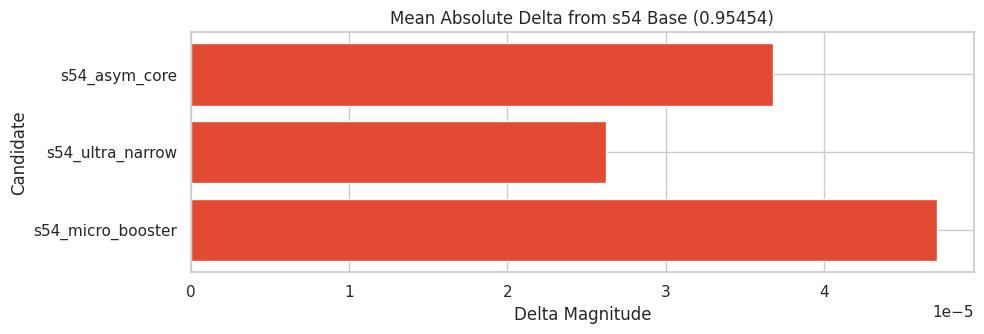

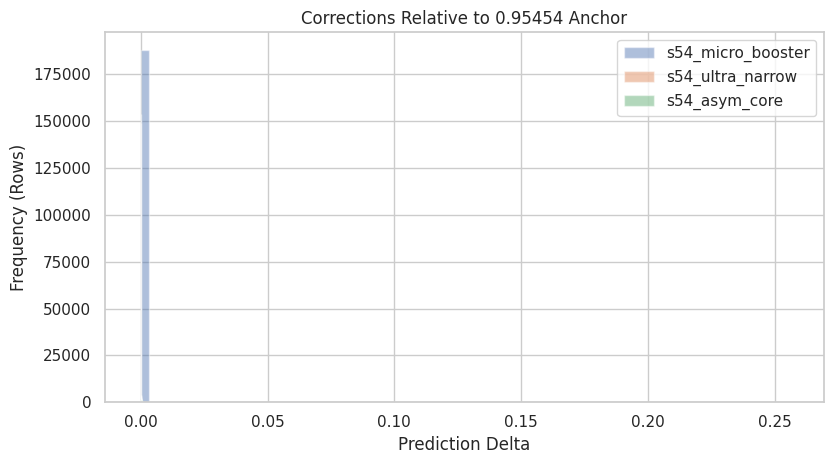

In [13]:
plot_df = s54_report[s54_report["candidate"].ne("s54_raw")].copy()
fig, ax = plt.subplots(figsize=(10, 3.5))
ax.barh(plot_df["candidate"], plot_df["delta_to_s54"], color="#E24A33")
ax.set_title("Mean Absolute Delta from s54 Base (0.95454)")
ax.set_xlabel("Delta Magnitude")
ax.set_ylabel("Candidate")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8.5, 4.8))
for candidate in ["s54_micro_booster", "s54_ultra_narrow", "s54_asym_core"]:
    pred = s54_candidates[candidate]["pred"]
    ax.hist(pred - s54_pred, bins=80, alpha=0.45, label=candidate)

ax.set_title("Corrections Relative to 0.95454 Anchor")
ax.set_xlabel("Prediction Delta")
ax.set_ylabel("Frequency (Rows)")
ax.legend()
plt.tight_layout()
plt.show()